In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

In [22]:
def generate_data(n_days: int = 365 * 2, seed: int = 42) -> pd.DataFrame:
    #Generate realistic daily electricity + temperature data.
    np.random.seed(seed)
    dates = pd.date_range("2022-01-01", periods=n_days, freq="D")

    # Base consumption with seasonal pattern (higher in summer/winter)
    day_of_year = np.arange(n_days)
    seasonal = 5 * np.cos(2 * np.pi * (day_of_year - 30) / 365)  # winter peak
    base = 25 + seasonal + np.random.normal(0, 2, n_days)

    # Weekend effect 
    is_weekend = pd.Series(dates).dt.dayofweek.isin([5, 6]).values
    base += is_weekend * 2.5

    # Inject anomalies
    anomaly_idx = np.random.choice(n_days, size=int(n_days * 0.02), replace=False)
    anomaly_values = base.copy()
    anomaly_values[anomaly_idx] += np.random.choice([-15, 20, 25], size=len(anomaly_idx))

    # Temperature: inversely correlated with comfort zone (hot summers, cold winters)
    temperature = 15 - 12 * np.cos(2 * np.pi * (day_of_year - 180) / 365)
    temperature += np.random.normal(0, 3, n_days)

    df = pd.DataFrame({
        "date": dates,
        "consumption_kwh": np.clip(anomaly_values, 5, None),
        "temperature_c": temperature,
        "is_weekend": is_weekend,
    })
    df["month"] = df["date"].dt.to_period("M")
    df["month_name"] = df["date"].dt.strftime("%b %Y")
    df["hour_placeholder"] = 0  # daily data; kept for extensibility
    return df

In [23]:
#1.Monthly Aggretion
def monthly_aggregation(df: pd.DataFrame) -> pd.DataFrame:
    monthly = (
        df.groupby("month")["consumption_kwh"]
        .agg(total="sum", mean="mean", std="std", max="max", min="min", count="count")
        .reset_index()
    )
    monthly["month_dt"] = monthly["month"].dt.to_timestamp()
    print("\n── MODULE 1: Monthly Aggregation ──")
    print(monthly[["month", "total", "mean", "std"]].to_string(index=False))
    return monthly

In [24]:
#2.Peak Usage Detection
def peak_usage_detection(df: pd.DataFrame, top_n: int = 10) -> pd.DataFrame:
    threshold = df["consumption_kwh"].quantile(0.95)
    peaks = df[df["consumption_kwh"] >= threshold].sort_values("consumption_kwh", ascending=False)
    print(f"\n── MODULE 2: Peak Usage Detection (top {top_n} days, threshold={threshold:.2f} kWh) ──")
    print(peaks[["date", "consumption_kwh", "temperature_c"]].head(top_n).to_string(index=False))
    return peaks


In [25]:
#3.Correlation with Temperature
def temperature_correlation(df: pd.DataFrame):
    r, p = stats.pearsonr(df["temperature_c"], df["consumption_kwh"])
    slope, intercept, *_ = stats.linregress(df["temperature_c"], df["consumption_kwh"])
    print(f"\n── MODULE 3: Temperature Correlation ──")
    print(f"  Pearson r = {r:.4f},  p-value = {p:.4e}")
    print(f"  Linear fit: consumption = {slope:.3f} × temp + {intercept:.3f}")
    return r, p, slope, intercept


In [26]:
#4.Anomaly Detection(Z-score+IQR)
def anomaly_detection(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # Z-score method
    df["z_score"] = stats.zscore(df["consumption_kwh"])
    df["anomaly_z"] = df["z_score"].abs() > 3.0

    # IQR method
    Q1 = df["consumption_kwh"].quantile(0.25)
    Q3 = df["consumption_kwh"].quantile(0.75)
    IQR = Q3 - Q1
    df["anomaly_iqr"] = (df["consumption_kwh"] < Q1 - 1.5 * IQR) | \
                        (df["consumption_kwh"] > Q3 + 1.5 * IQR)

    df["anomaly"] = df["anomaly_z"] | df["anomaly_iqr"]
    anomalies = df[df["anomaly"]].sort_values("consumption_kwh", ascending=False)

    print(f"\n── MODULE 4: Anomaly Detection ──")
    print(f"  Z-score anomalies : {df['anomaly_z'].sum()}")
    print(f"  IQR anomalies     : {df['anomaly_iqr'].sum()}")
    print(f"  Combined (union)  : {df['anomaly'].sum()}")
    print(anomalies[["date", "consumption_kwh", "z_score"]].head(10).to_string(index=False))
    return df


In [27]:
#5.Confidence Interval For Mean Consumption
def confidence_interval(df: pd.DataFrame, ci: float = 0.95) -> tuple:
    data = df["consumption_kwh"].dropna()
    mean = data.mean()
    se = stats.sem(data)
    lo, hi = stats.t.interval(ci, df=len(data) - 1, loc=mean, scale=se)
    print(f"\n── MODULE 5: {int(ci*100)}% Confidence Interval for Mean ──")
    print(f"  n     = {len(data)}")
    print(f"  mean  = {mean:.4f} kWh")
    print(f"  std   = {data.std():.4f} kWh")
    print(f"  CI    = [{lo:.4f}, {hi:.4f}] kWh")
    return mean, lo, hi

In [28]:
#6.Energy Efficiency Interpretation
def energy_efficiency(df: pd.DataFrame, monthly: pd.DataFrame):
    avg_monthly = monthly["total"].mean()
    # Simple baseline: Indian residential benchmark ~200-400 kWh/month
    benchmark_low, benchmark_high = 200, 400
    category = (
        "Low (Efficient)" if avg_monthly < benchmark_low else
        "Moderate" if avg_monthly <= benchmark_high else
        "High (Inefficient)"
    )
    yoy = None
    if len(monthly) >= 24:
        first_year = monthly["total"].iloc[:12].mean()
        second_year = monthly["total"].iloc[12:24].mean()
        yoy = (second_year - first_year) / first_year * 100

    print(f"\n── MODULE 6: Energy Efficiency Interpretation ──")
    print(f"  Avg monthly consumption : {avg_monthly:.1f} kWh")
    print(f"  Efficiency category     : {category}")
    if yoy is not None:
        direction = "increase" if yoy > 0 else "decrease"
        print(f"  Year-over-year change   : {abs(yoy):.1f}% {direction}")

    # Weekend vs weekday
    wd = df[~df["is_weekend"]]["consumption_kwh"].mean()
    we = df[df["is_weekend"]]["consumption_kwh"].mean()
    print(f"  Weekday avg             : {wd:.2f} kWh")
    print(f"  Weekend avg             : {we:.2f} kWh (+{(we-wd)/wd*100:.1f}%)")

In [29]:
#7.Visualization
def plot_all(df: pd.DataFrame, monthly: pd.DataFrame,
             peaks: pd.DataFrame, mean: float, lo: float, hi: float,
             slope: float, intercept: float):

    sns.set_theme(style="whitegrid", palette="muted")
    fig = plt.figure(figsize=(18, 14))
    fig.suptitle("Electricity Consumption Pattern & Anomaly Detection", fontsize=16, fontweight="bold")
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

    # ── 1. Monthly Total Bar ──
    ax1 = fig.add_subplot(gs[0, :2])
    ax1.bar(range(len(monthly)), monthly["total"], color=sns.color_palette("Blues_d", len(monthly)))
    ax1.set_xticks(range(len(monthly)))
    ax1.set_xticklabels(
        [str(m) for m in monthly["month"]], rotation=45, ha="right", fontsize=7
    )
    ax1.set_title("Module 1 – Monthly Total Consumption (kWh)")
    ax1.set_ylabel("kWh")

    # ── 2. Peak Usage Highlighting ──
    ax2 = fig.add_subplot(gs[0, 2])
    peak_dates = peaks["date"].values
    colors = ["tomato" if d in peak_dates else "steelblue" for d in df["date"].values]
    ax2.scatter(df["date"], df["consumption_kwh"], c=colors, s=4, alpha=0.6)
    ax2.set_title("Module 2 – Peak Days (red)")
    ax2.set_ylabel("kWh")
    ax2.tick_params(axis="x", rotation=30, labelsize=7)

    # ── 3. Temperature Scatter + Regression ──
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.scatter(df["temperature_c"], df["consumption_kwh"], alpha=0.3, s=10, color="teal")
    x_line = np.linspace(df["temperature_c"].min(), df["temperature_c"].max(), 200)
    ax3.plot(x_line, slope * x_line + intercept, color="crimson", lw=2, label="Fit")
    ax3.set_xlabel("Temperature (°C)")
    ax3.set_ylabel("kWh")
    ax3.set_title("Module 3 – Temp vs Consumption")
    ax3.legend(fontsize=8)

    # ── 4. Anomaly Detection Plot ──
    ax4 = fig.add_subplot(gs[1, 1])
    normal = df[~df["anomaly"]]
    anomalous = df[df["anomaly"]]
    ax4.scatter(normal["date"], normal["consumption_kwh"], s=5, color="steelblue", alpha=0.5, label="Normal")
    ax4.scatter(anomalous["date"], anomalous["consumption_kwh"], s=30, color="red", zorder=5, label="Anomaly")
    ax4.set_title("Module 4 – Anomaly Detection")
    ax4.set_ylabel("kWh")
    ax4.legend(fontsize=8)
    ax4.tick_params(axis="x", rotation=30, labelsize=7)

    # ── 5. Confidence Interval Visualization ──
    ax5 = fig.add_subplot(gs[1, 2])
    ax5.hist(df["consumption_kwh"], bins=40, color="skyblue", edgecolor="white", density=True)
    ax5.axvline(mean, color="navy", lw=2, label=f"Mean={mean:.1f}")
    ax5.axvline(lo, color="orange", lw=1.5, linestyle="--", label=f"95% CI [{lo:.1f}, {hi:.1f}]")
    ax5.axvline(hi, color="orange", lw=1.5, linestyle="--")
    ax5.set_title("Module 5 – Consumption Distribution & CI")
    ax5.set_xlabel("kWh")
    ax5.legend(fontsize=8)

    # ── 6. Efficiency: Monthly Mean + Weekend vs Weekday ──
    ax6 = fig.add_subplot(gs[2, :2])
    monthly_copy = monthly.copy()
    ax6.plot(range(len(monthly_copy)), monthly_copy["mean"], marker="o", color="darkorange", lw=2)
    ax6.axhline(monthly_copy["mean"].mean(), color="gray", linestyle="--", label="Overall mean")
    ax6.fill_between(range(len(monthly_copy)),
                     monthly_copy["mean"] - monthly_copy["std"],
                     monthly_copy["mean"] + monthly_copy["std"],
                     alpha=0.2, color="darkorange")
    ax6.set_xticks(range(len(monthly_copy)))
    ax6.set_xticklabels([str(m) for m in monthly_copy["month"]], rotation=45, ha="right", fontsize=7)
    ax6.set_title("Module 6 – Monthly Mean ± Std (Efficiency Trend)")
    ax6.set_ylabel("Avg kWh/day")
    ax6.legend(fontsize=8)

    # ── Weekday vs Weekend box ──
    ax7 = fig.add_subplot(gs[2, 2])
    groups = [df[~df["is_weekend"]]["consumption_kwh"].values,
              df[df["is_weekend"]]["consumption_kwh"].values]
    bp = ax7.boxplot(groups, labels=["Weekday", "Weekend"], patch_artist=True,
                     boxprops=dict(facecolor="lightblue"))
    ax7.set_title("Module 6 – Weekday vs Weekend")
    ax7.set_ylabel("kWh")

    plt.savefig("electricity_analysis.png", dpi=150, bbox_inches="tight")
    print("\n  Chart saved → electricity_analysis.png")
    plt.show()

  Electricity Consumption Pattern & Anomaly Study

── MODULE 1: Monthly Aggregation ──
  month      total      mean      std
2022-01 935.599151 30.180618 2.012272
2022-02 846.336205 30.226293 1.917060
2022-03 974.018124 31.419939 7.109338
2022-04 863.466895 28.782230 6.248954
2022-05 756.386623 24.399568 2.487746
2022-06 685.096860 22.836562 2.113659
2022-07 659.064924 21.260159 2.145851
2022-08 645.242190 20.814264 2.347913
2022-09 658.520748 21.950692 2.885364
2022-10 763.008831 24.613188 2.232187
2022-11 821.215931 27.373864 2.064162
2022-12 901.804393 29.090464 2.110879
2023-01 954.841364 30.801334 2.595120
2023-02 883.526942 31.554534 4.603668
2023-03 878.535300 28.339848 3.372580
2023-04 813.729475 27.124316 2.493174
2023-05 737.199595 23.780632 3.119518
2023-06 645.724529 21.524151 2.294080
2023-07 672.097404 21.680561 4.507244
2023-08 675.193762 21.780444 4.126847
2023-09 696.669513 23.222317 5.252464
2023-10 735.983540 23.741405 6.151532
2023-11 808.097532 26.936584 2.531201
2

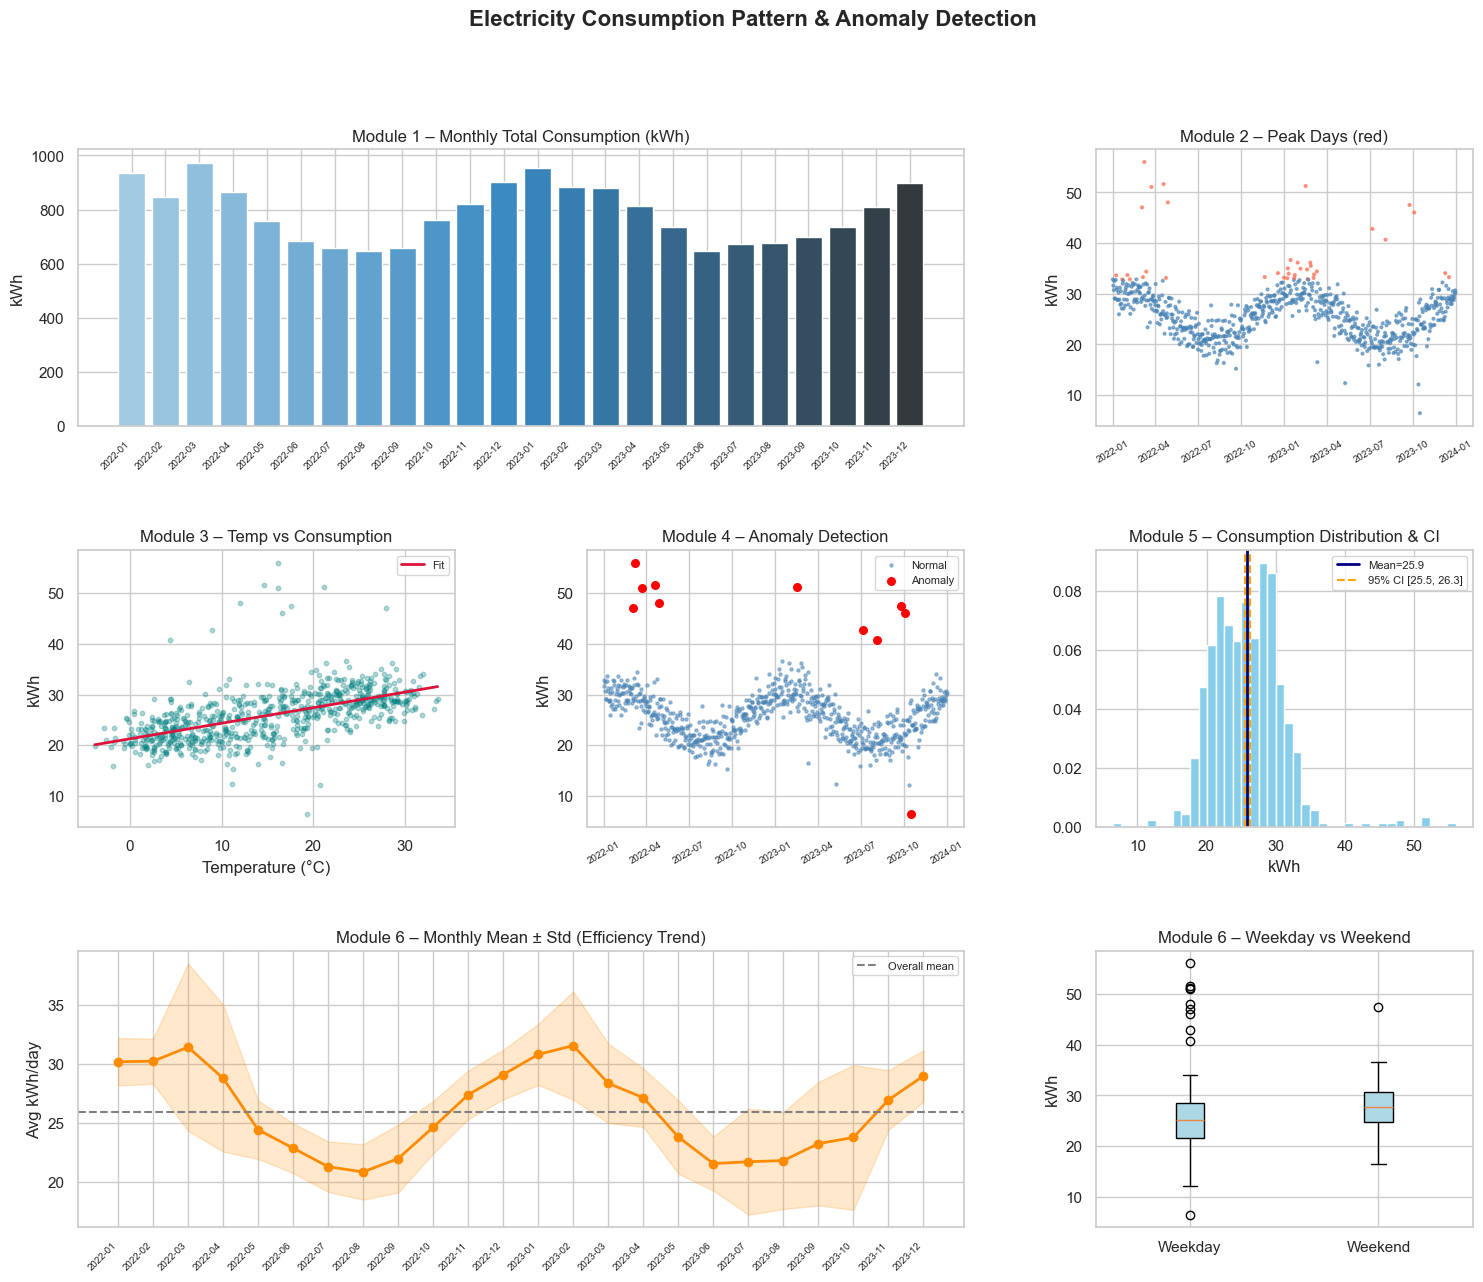


✓ Analysis complete.


In [30]:
if __name__ == "__main__":
    print("=" * 55)
    print("  Electricity Consumption Pattern & Anomaly Study")
    print("=" * 55)

    # 0. Data
    df_raw = generate_data(n_days=365 * 2)

    # 1. Monthly aggregation
    monthly = monthly_aggregation(df_raw)

    # 2. Peak detection
    peaks = peak_usage_detection(df_raw, top_n=10)

    # 3. Temperature correlation
    r, p, slope, intercept = temperature_correlation(df_raw)

    # 4. Anomaly detection (enriches df)
    df = anomaly_detection(df_raw)

    # 5. Confidence interval
    mean, lo, hi = confidence_interval(df)

    # 6. Efficiency
    energy_efficiency(df, monthly)

    # Visualize
    plot_all(df, monthly, peaks, mean, lo, hi, slope, intercept)

    print("\n✓ Analysis complete.")